# Stochastic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network via SimPy discrete-event simulation across the full adaptation axis, and cross-check against the analytic closed-form solution.

**Inputs**:
- `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts; same source as the analytic method).
- `data/config/method/stochastic.json` (SimPy method parameters: seed, replications, horizon / warmup in invocations, ...).
- `data/reference/baseline.json` (R1 / R2 / R3 thresholds).

**Outputs**:
- `data/results/stochastic/<adaptation>/<profile>.json` - per-run metrics (nodes with `_std` columns + network aggregate + routing + `lambda_z` + embedded `method_config`).
- `data/results/stochastic/<adaptation>/requirements.json` - R1 / R2 / R3 verdicts.
- `data/img/stochastic/<adaptation>/*.{png,svg}` - topology, heatmap, diffmap, CI bars, network bars, delta figures.

**Equivalent CLI**:
```bash
python -m src.methods.stochastic --adaptation baseline
python -m src.methods.stochastic --adaptation s1
python -m src.methods.stochastic --adaptation s2
python -m src.methods.stochastic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.stochastic` and `src.view.qn_diagram`. The cells below orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run as run_analytic
from src.methods.stochastic import run as run_stochastic
from src.view import (
    plot_qn_topology,
    plot_nd_heatmap,
    plot_nd_diffmap,
    plot_nd_ci,
    plot_net_bars,
    plot_net_delta,
)

_IMG_ROOT = Path("data/img/stochastic")
_ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
_DISPLAY = {
    "baseline":  "Before Adaptation",
    "s1":        "S1: Service-Failure Adapt.",
    "s2":        "S2: Response-Time Adapt.",
    "aggregate": "After Adaptation",
}

## 1. Solve every adaptation (SimPy DES)

`run_stochastic(adp=a, wrt=True)` loads `NetworkConfig`, pulls the method config (seed / replications / horizon / warmup), runs the DES engine across every replication, writes the JSON envelope, and returns the per-replication-averaged per-node frame + network aggregate + R1 / R2 / R3 verdict.

In [2]:
_results = {_a: run_stochastic(adp=_a, wrt=True) for _a in _ADAPTATIONS}

_cfgs = {_a: _results[_a]["config"] for _a in _ADAPTATIONS}
_nodes = {_a: _results[_a]["nodes"] for _a in _ADAPTATIONS}
_nets = {_a: _results[_a]["network"] for _a in _ADAPTATIONS}
_reqs = {_a: _results[_a]["requirements"] for _a in _ADAPTATIONS}
_mc = _results["baseline"]["method_config"]

# analytic baseline cached once for the CI overlay reference in section 6
_analytic_baseline_nodes = run_analytic(adp="baseline", wrt=False)["nodes"]

print(f"Solved {len(_results)} adaptations via SimPy DES; "
      f"seed={_mc['seed']} reps={_mc['replications']} "
      f"horizon={_mc['horizon_invocations']} inv. "
      f"warmup={_mc['warmup_invocations']} inv.")

Solved 4 adaptations via SimPy DES; seed=42 reps=10 horizon=10000 inv. warmup=1000 inv.


## 2. Network-wide summary + verdict

One row per adaptation: mean headline metrics across replications and the R1 / R2 / R3 pass flags.

In [3]:
_rows = []
for _a in _ADAPTATIONS:
    _n = _nets[_a].iloc[0]
    _r = _reqs[_a]
    _rows.append({
        "adaptation": _a,
        "profile": _cfgs[_a].profile,
        "W_net (ms)": _n["W_net"] * 1000,
        "avg_rho": _n["avg_rho"],
        "max_rho": _n["max_rho"],
        "L_net": _n["L_net"],
        "R1": "PASS" if _r["R1"]["pass"] else "FAIL",
        "R2": "PASS" if _r["R2"]["pass"] else "FAIL",
        "R3": "PASS" if _r["R3"]["pass"] else "FAIL",
    })
pd.DataFrame(_rows).set_index("adaptation").round(4)

,profile,W_net (ms),avg_rho,max_rho,L_net,R1,R2,R3
adaptation,,,,,,,,
baseline,dflt,3.4569,0.2977,0.6931,7.0668,PASS,PASS,PASS
s1,opti,3.3691,0.2877,0.7296,6.7844,PASS,PASS,PASS
s2,opti,3.5913,0.3054,0.7102,7.3382,PASS,PASS,PASS
aggregate,opti,3.0998,0.2837,0.6907,6.2685,PASS,PASS,PASS


## 3. Per-node snapshot (baseline, mean across reps)

Mean per-node metrics after the warm-up cut-off. The `_std` companions carry the replication-to-replication spread; the CI overlay in section 6 uses them.

In [4]:
_nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "rho_std", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,rho_std,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,346.4490,898.5211,1,10,0.3856,0.0056,0.6258,0.0018
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,259.9843,704.2618,1,10,0.3692,0.0068,0.5869,0.0023
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,173.0482,697.4507,1,10,0.2482,0.0059,0.3301,0.0019
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,97.7347,179.9978,1,10,0.5433,0.0187,1.1900,0.0122
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,92.3067,525.7131,1,10,0.1756,0.0051,0.2121,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,103.8143,149.8593,1,10,0.6931,0.0251,2.1043,0.0203
6,AS_{1},Alarm Service 1,M/M/s/K,63.5988,698.2111,1,10,0.0911,0.0028,0.1006,0.0016
7,AS_{2},Alarm Service 2,M/M/s/K,59.5777,411.9339,1,10,0.1446,0.0022,0.1684,0.0028
8,AS_{3},Alarm Service 3,M/M/s/K,70.3110,1597.9171,1,10,0.0440,0.0014,0.0462,0.0007
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,256.6263,702.7465,1,10,0.3652,0.0064,0.5777,0.0023


## 4. Queue-network topology per adaptation

Nodes coloured by rho (cool = low, warm = high), scaled to the frame's max. Same plotter as the analytic notebook so the two methods compare visually.

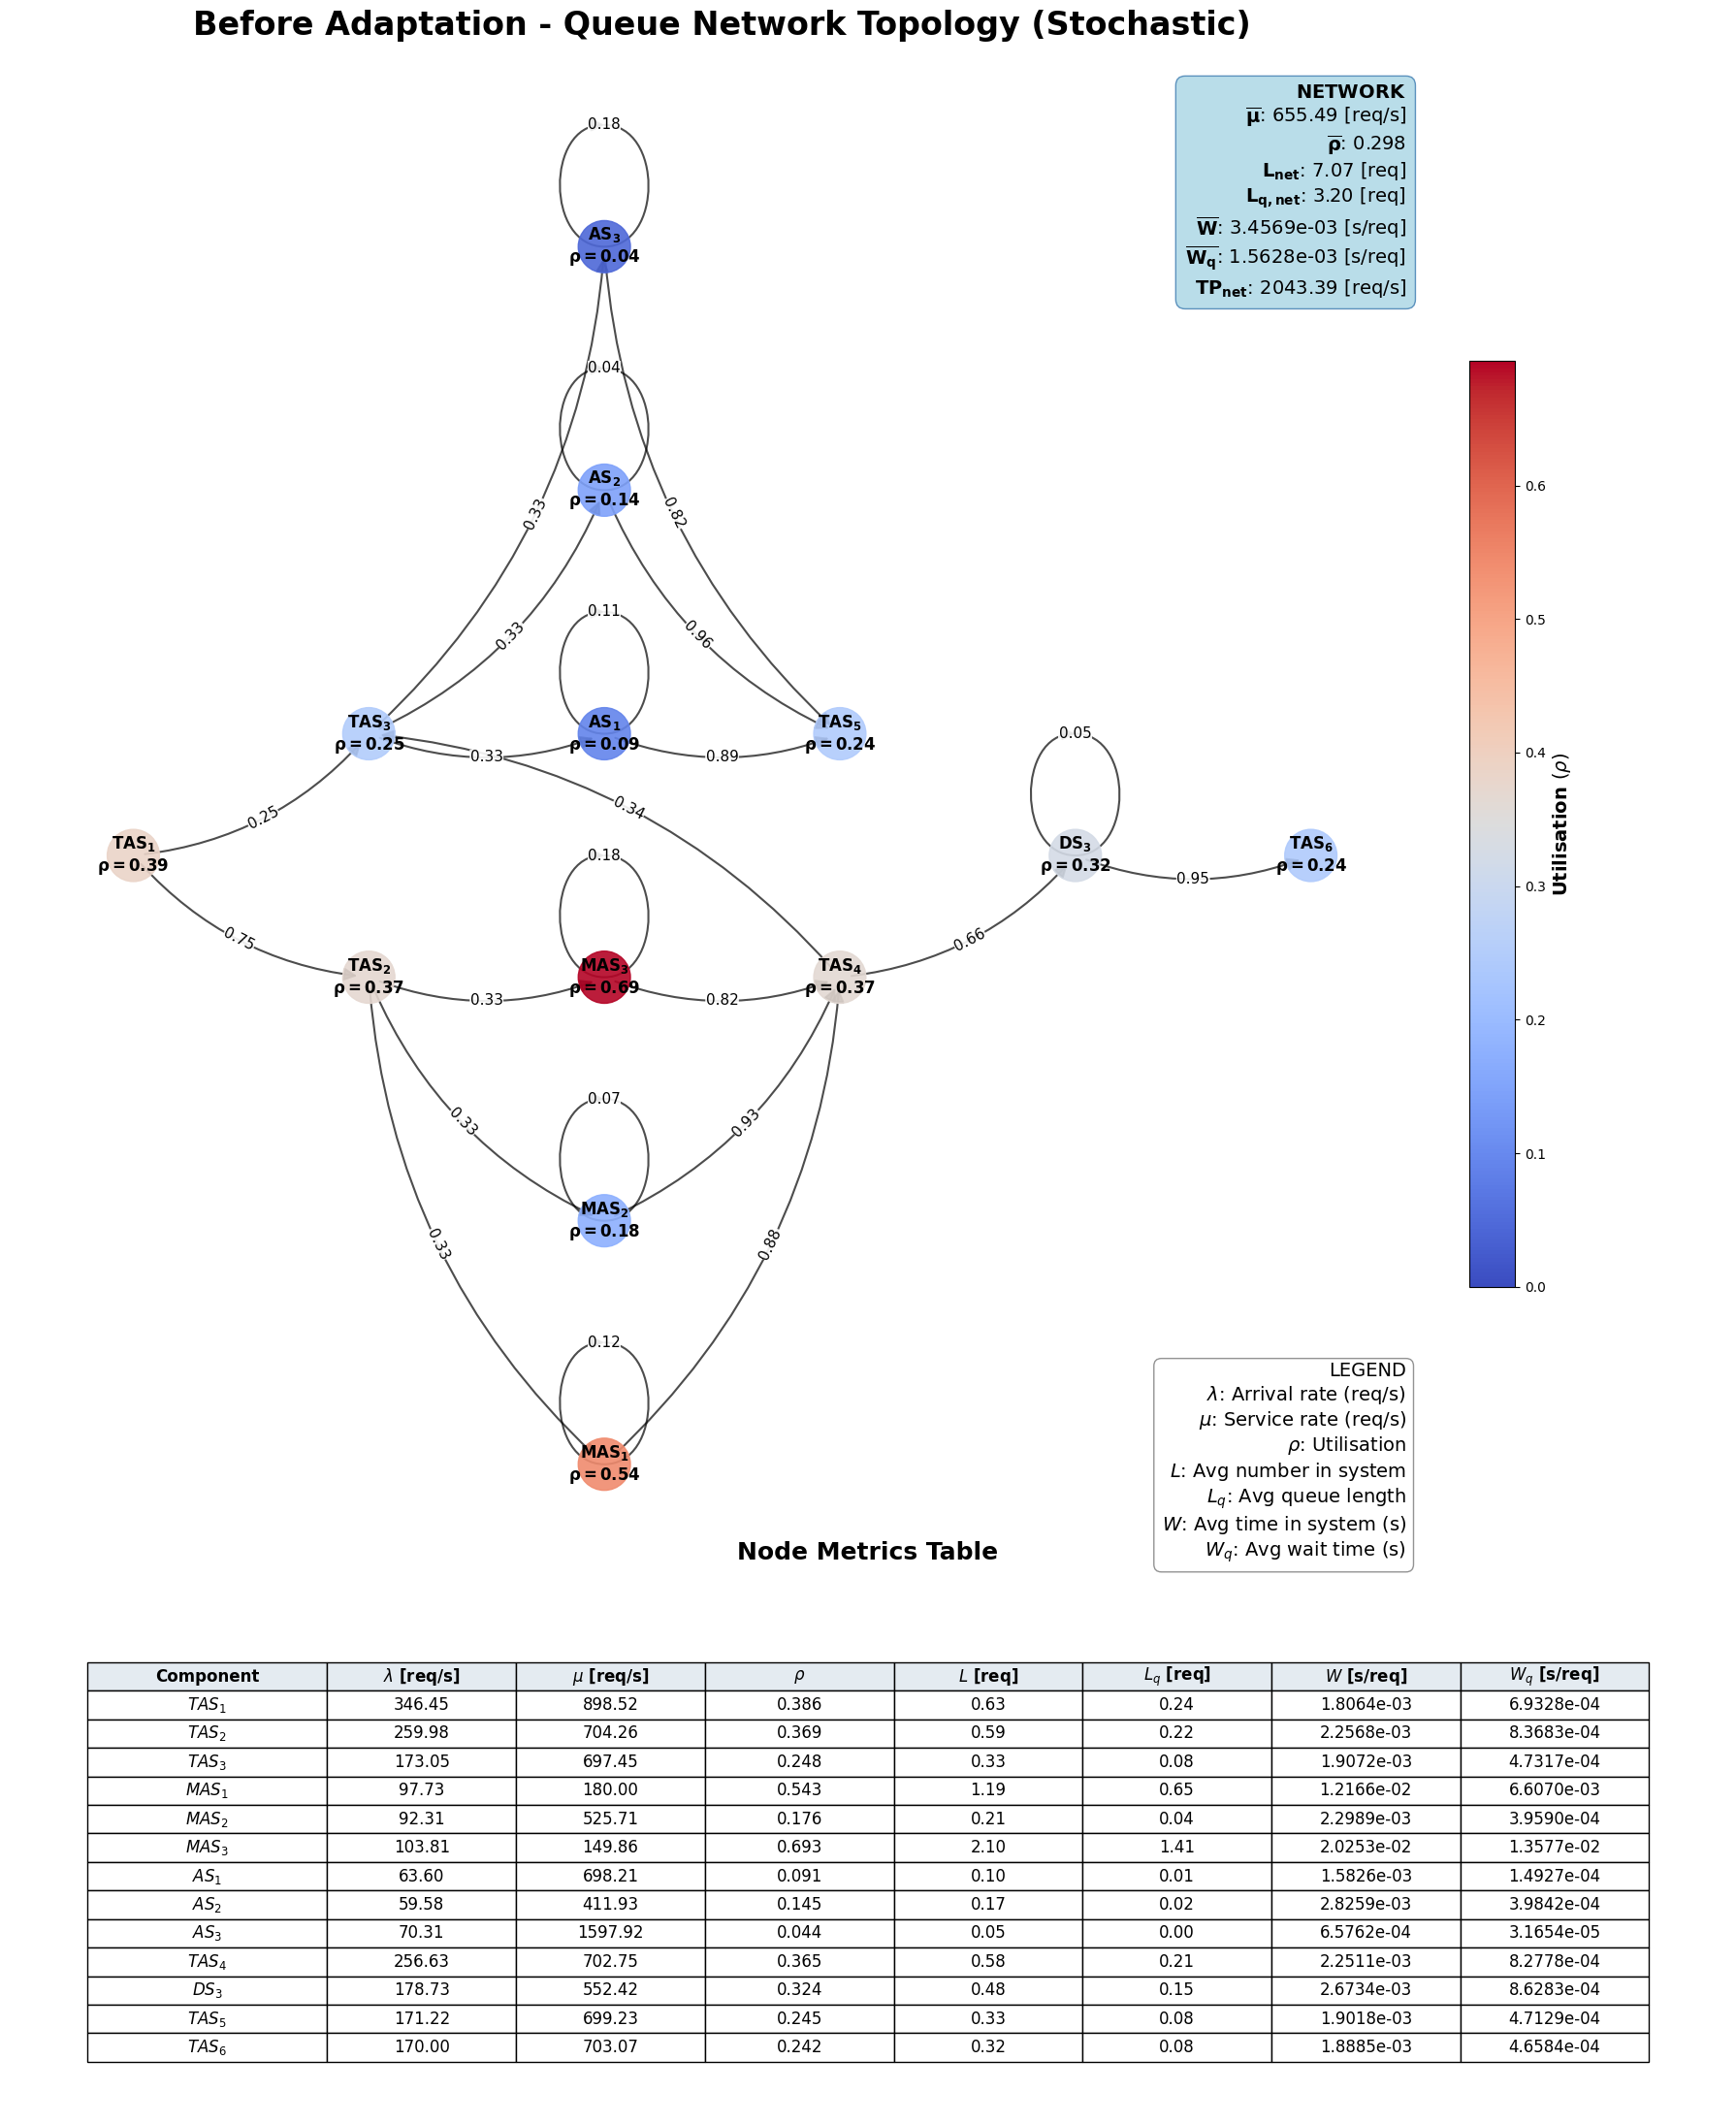

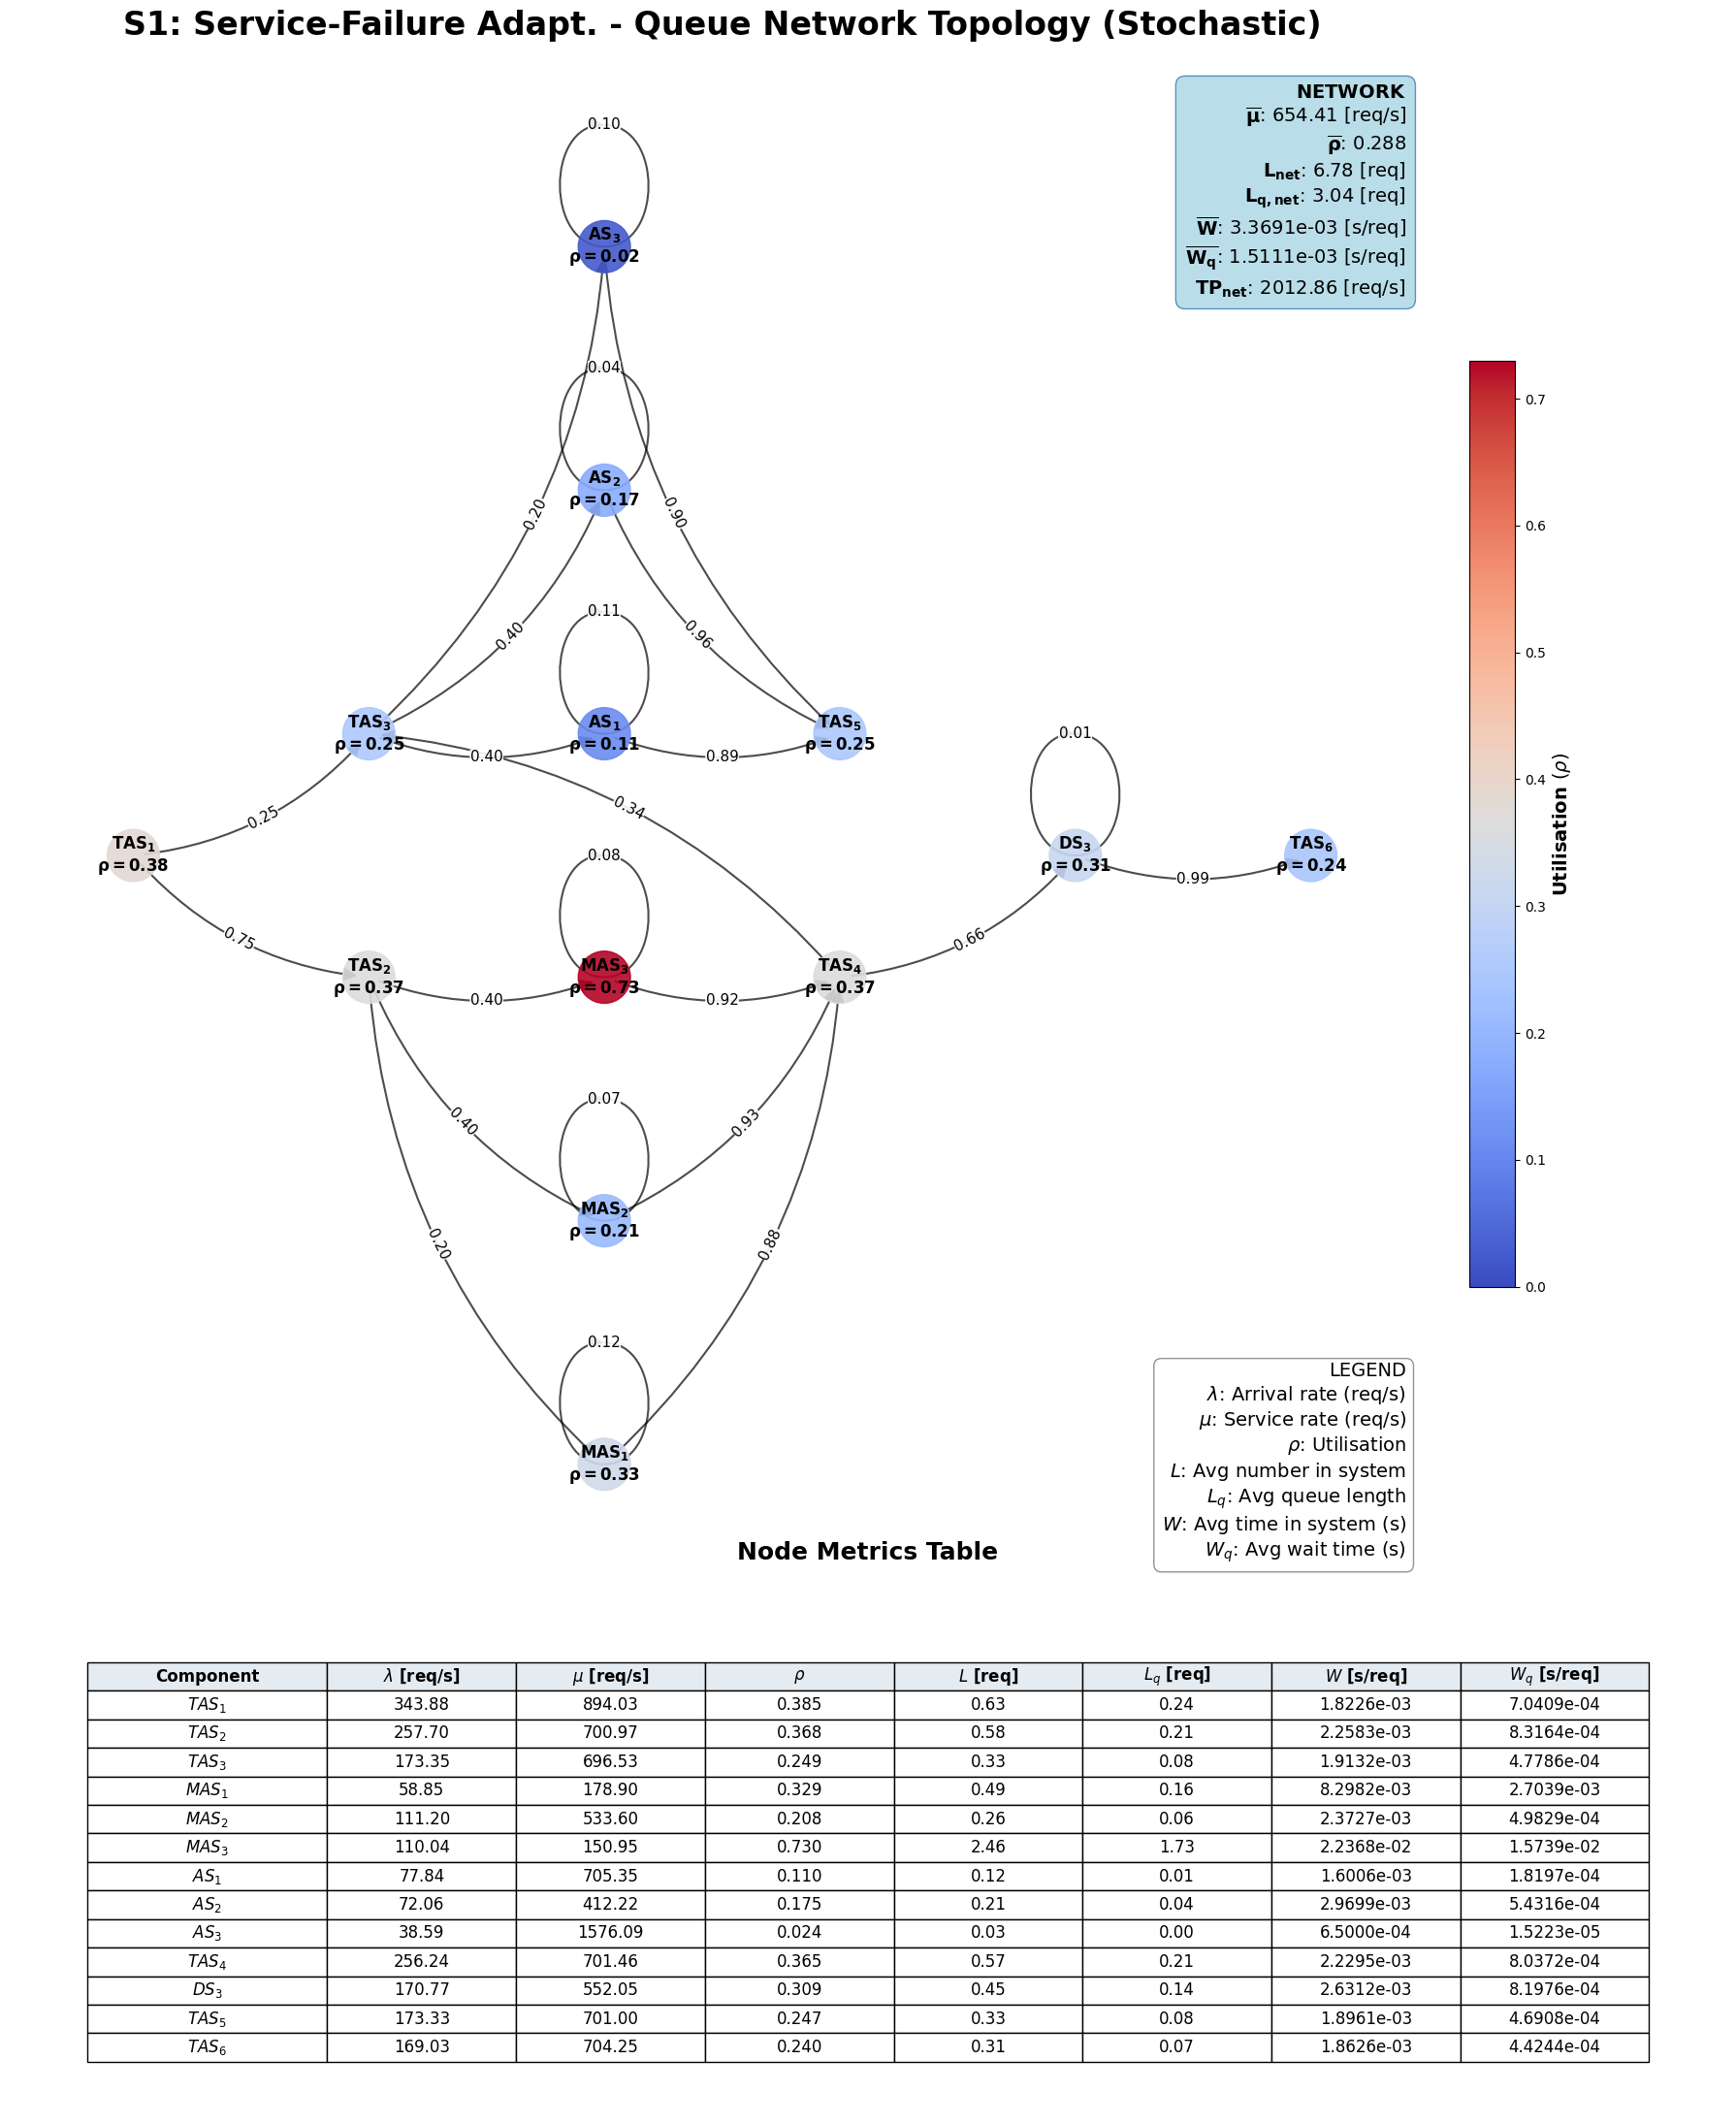

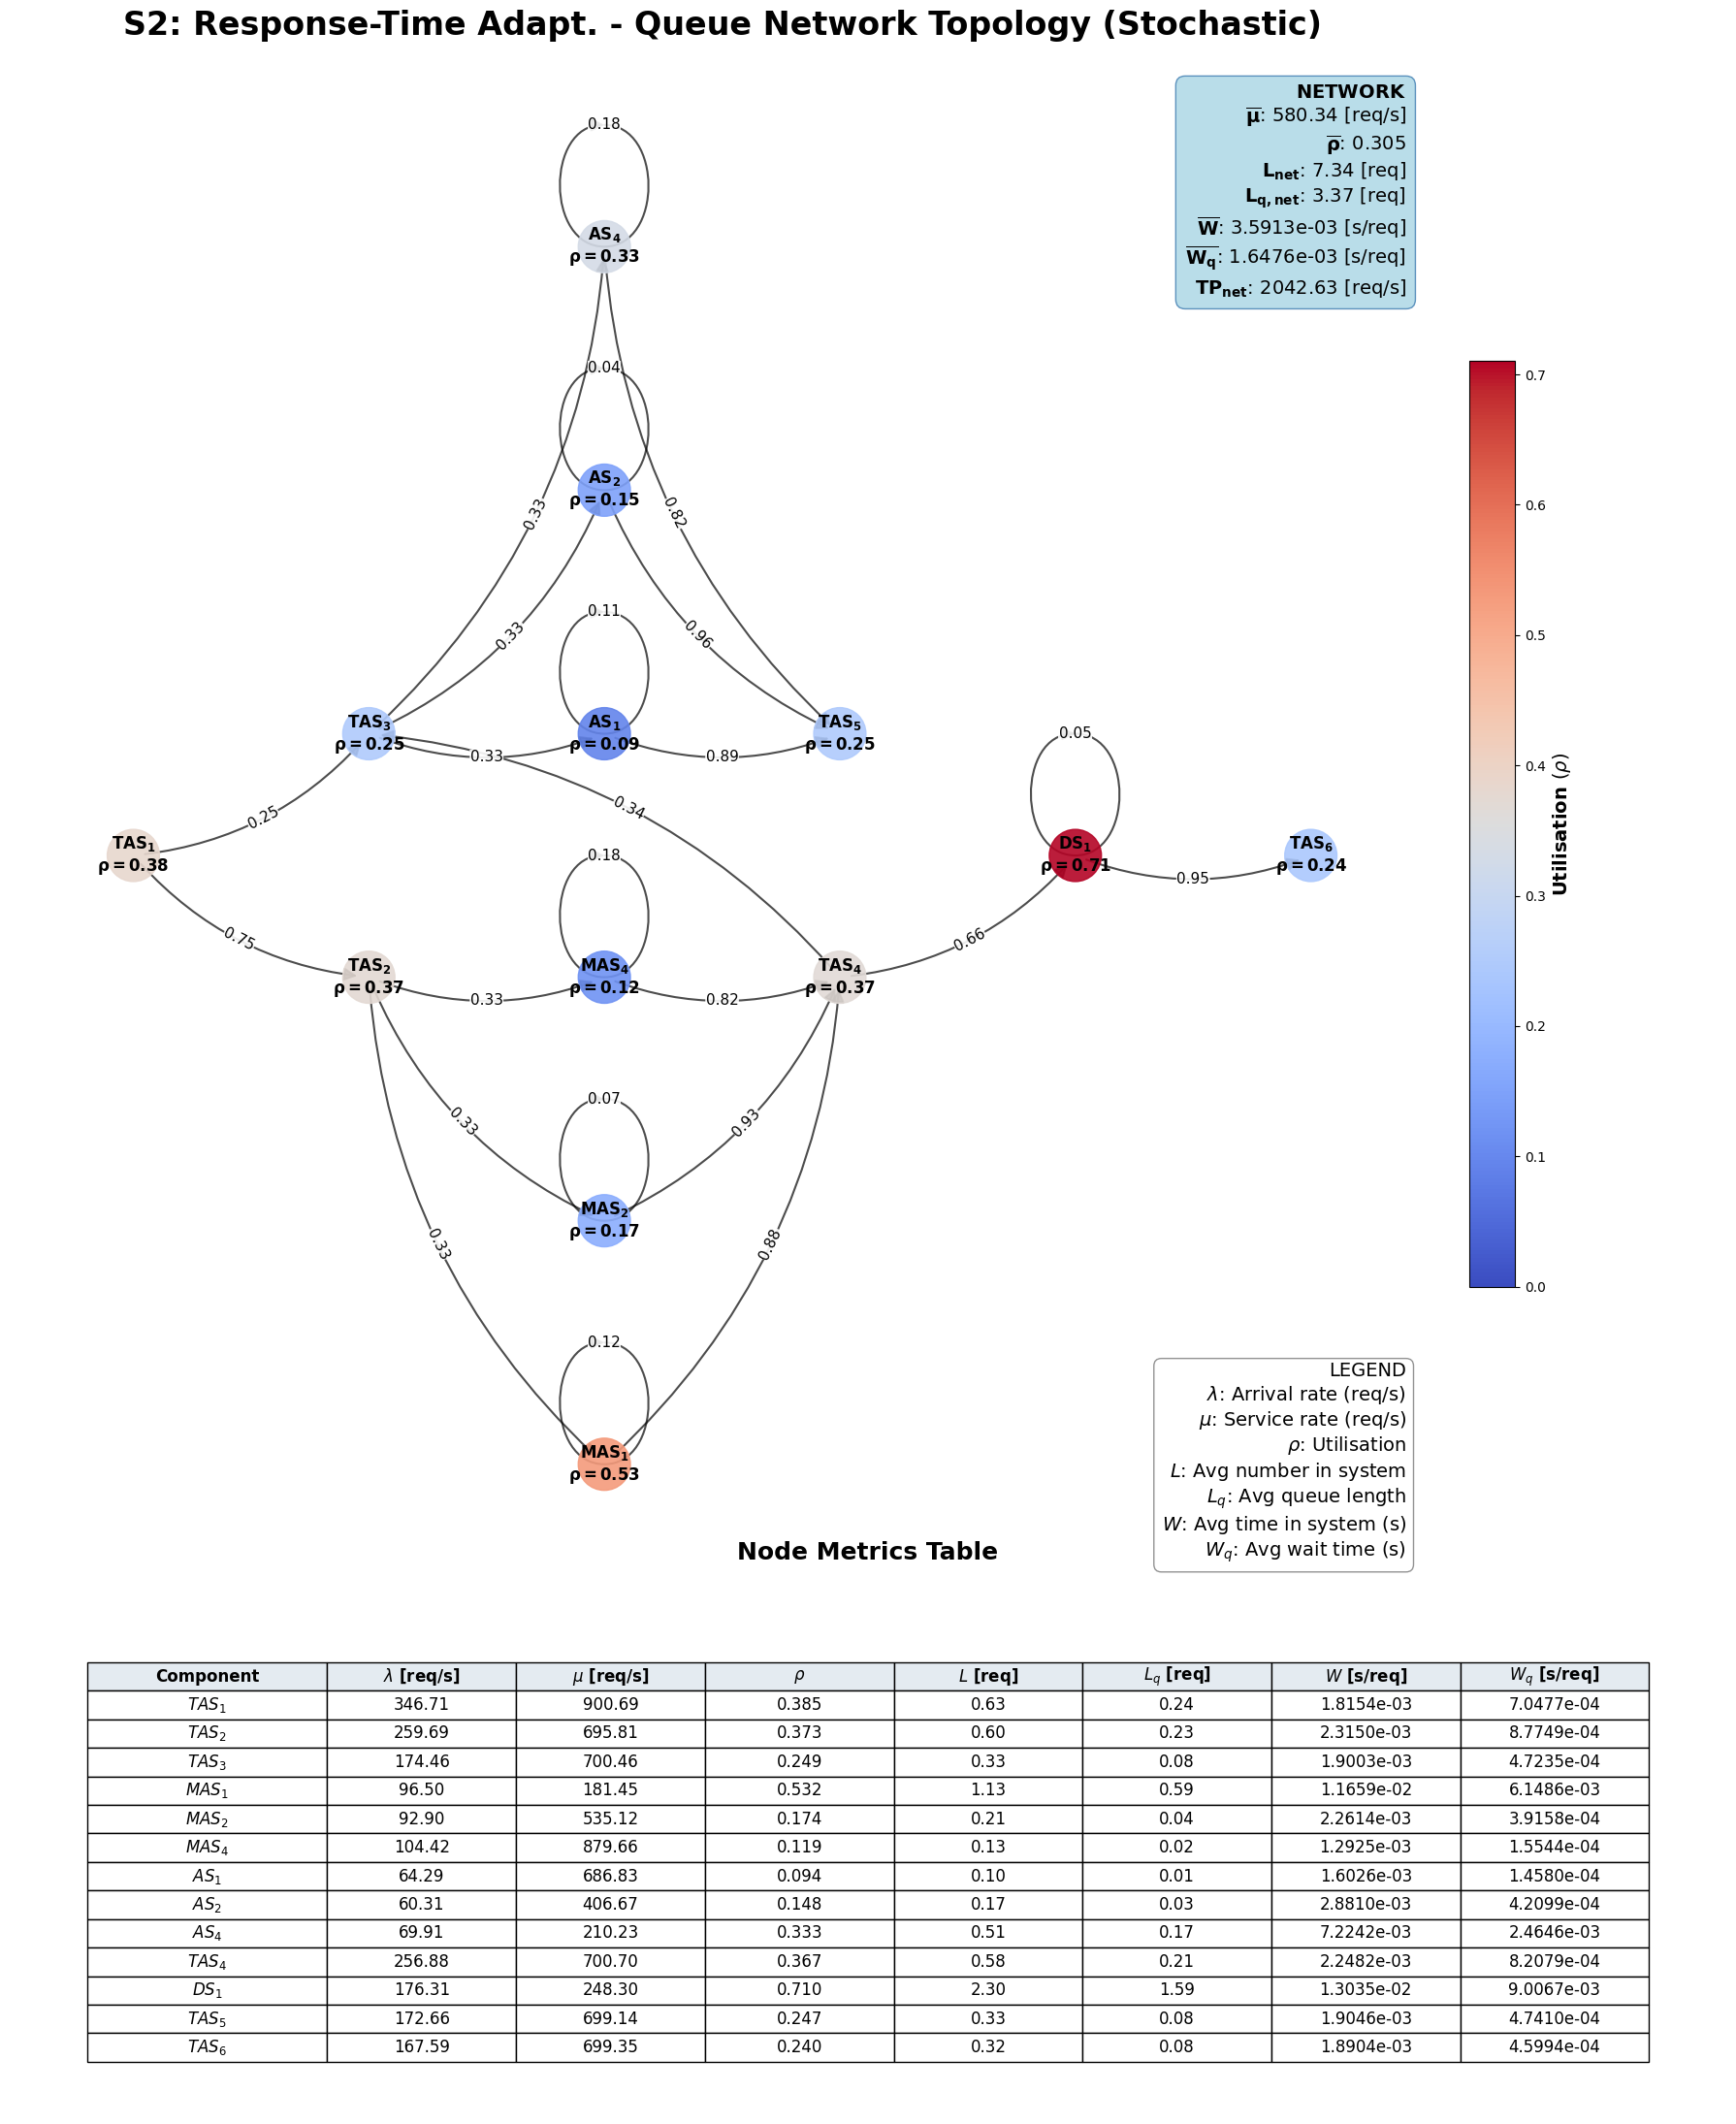

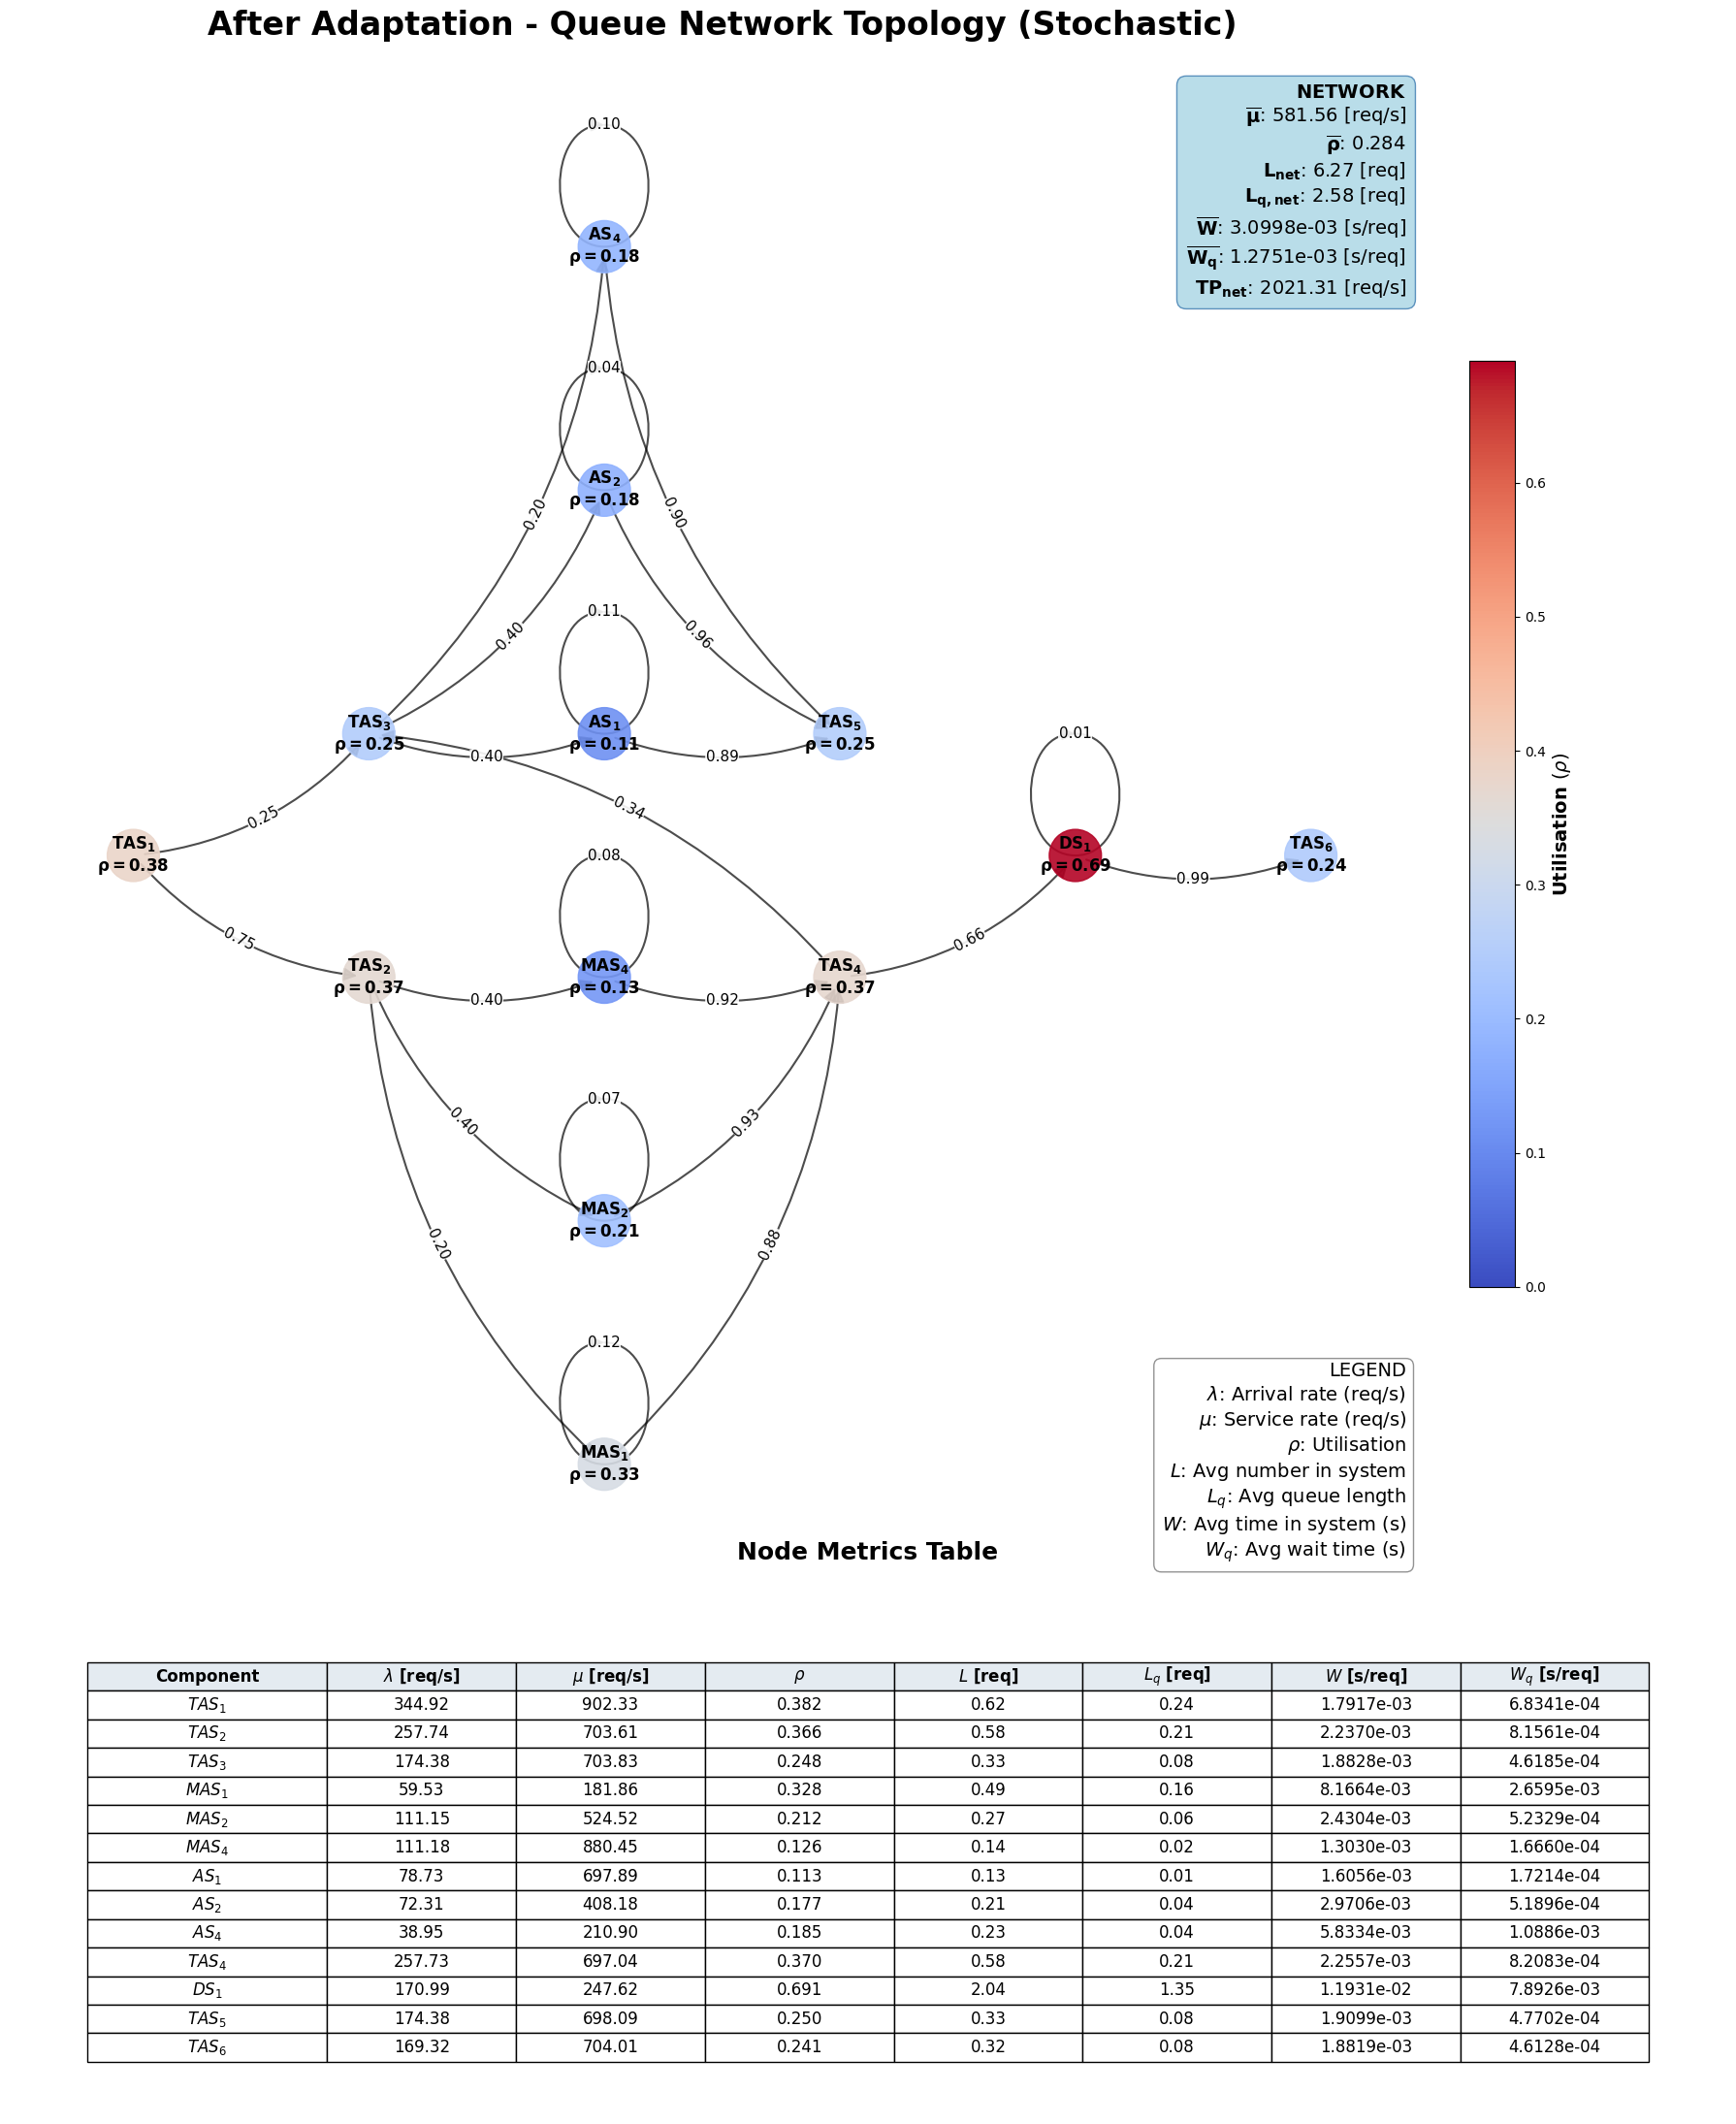

In [5]:
for _a in _ADAPTATIONS:
    plot_qn_topology(
        rout=_cfgs[_a].routing,
        nds=_nodes[_a],
        net=_nets[_a],
        title=f"{_DISPLAY[_a]} - Queue Network Topology (Stochastic)",
        file_path=str(_IMG_ROOT / _a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns normalised per-metric across both scenarios.

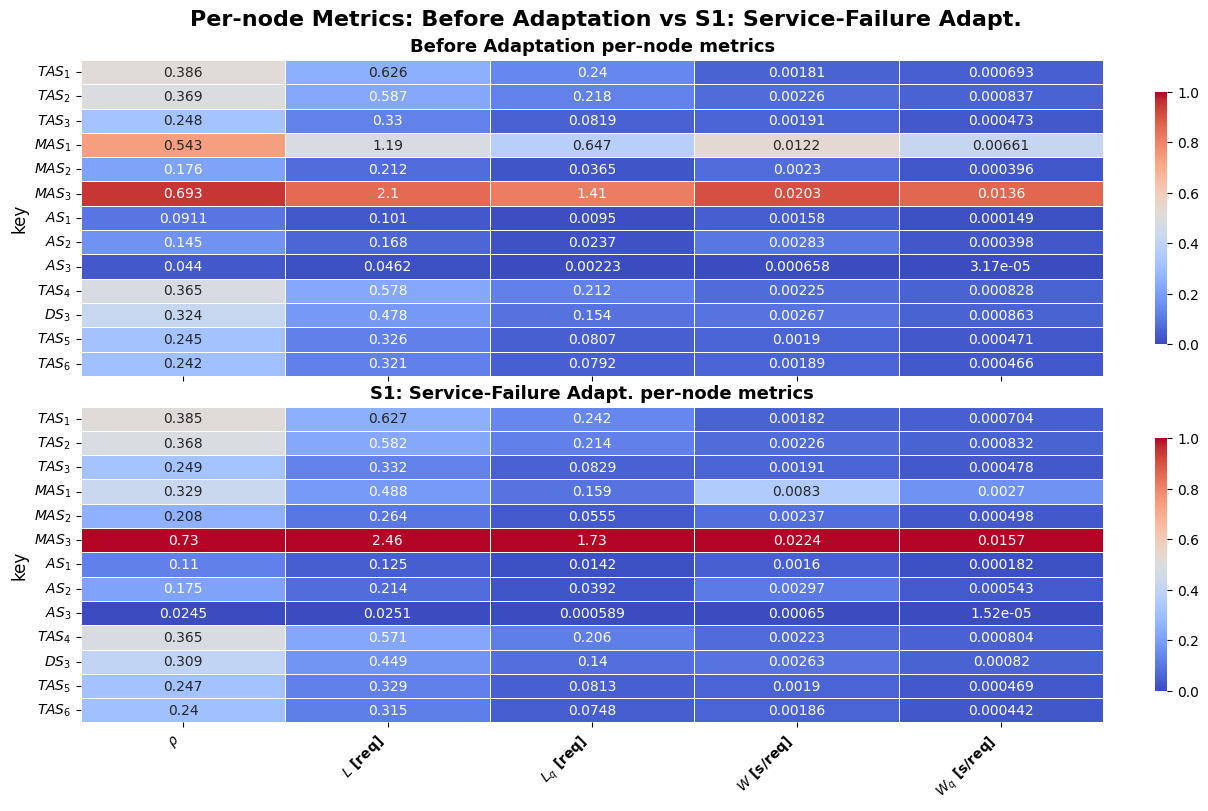

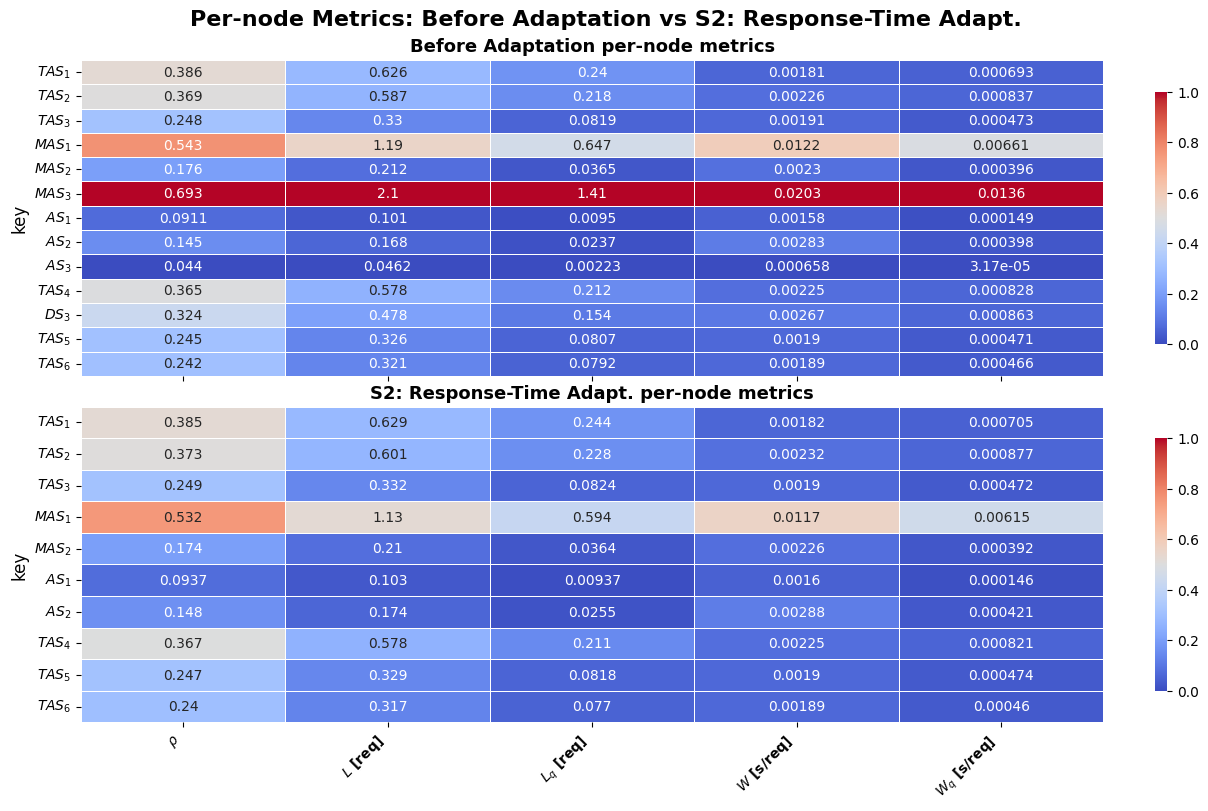

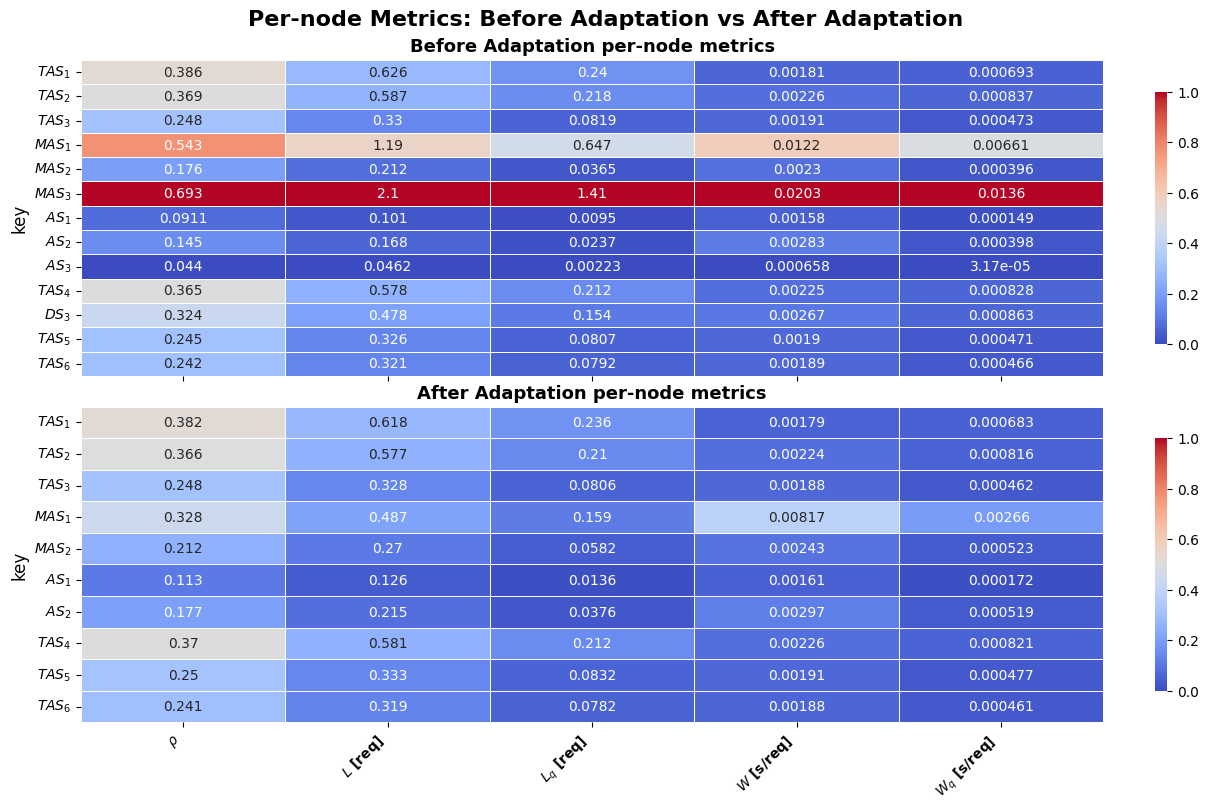

In [6]:
_node_keys = _nodes["baseline"]["key"].tolist()
_heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
_heat_labels = [
    r"$\rho$",
    r"$L$ [req]",
    r"$L_q$ [req]",
    r"$W$ [s/req]",
    r"$W_q$ [s/req]",
]

for _a in ["s1", "s2", "aggregate"]:
    plot_nd_heatmap(
        ndss=[_nodes["baseline"], _nodes[_a]],
        names=[_DISPLAY["baseline"], _DISPLAY[_a]],
        nodes=_node_keys,
        metrics=_heat_metrics,
        labels=_heat_labels,
        title=f"Per-node Metrics: {_DISPLAY['baseline']} vs {_DISPLAY[_a]}",
        file_path=str(_IMG_ROOT / _a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (ratio vs baseline)

Same `(opti - dflt) / |dflt|` ratio convention as the analytic method (matches `__OLD__/src/exports/analytical_draft.py`). Values render as fractions: 35.82 reads as 3582 %.

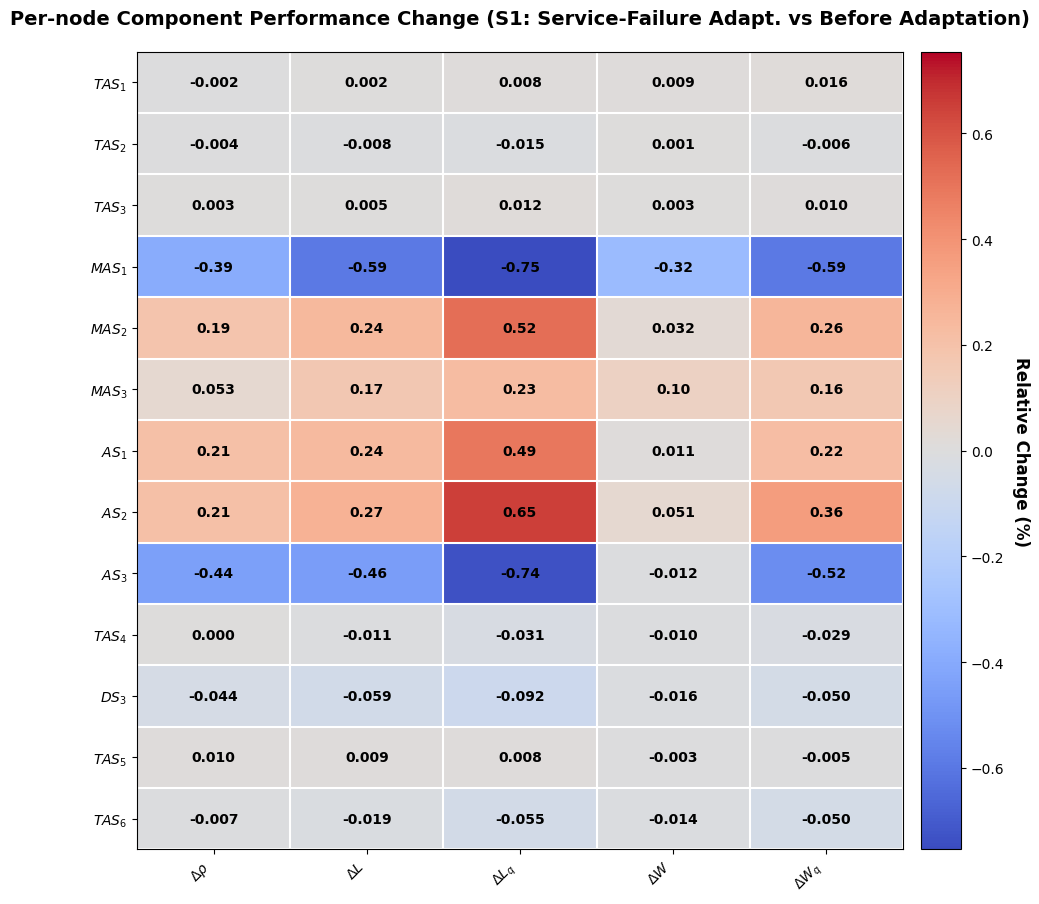

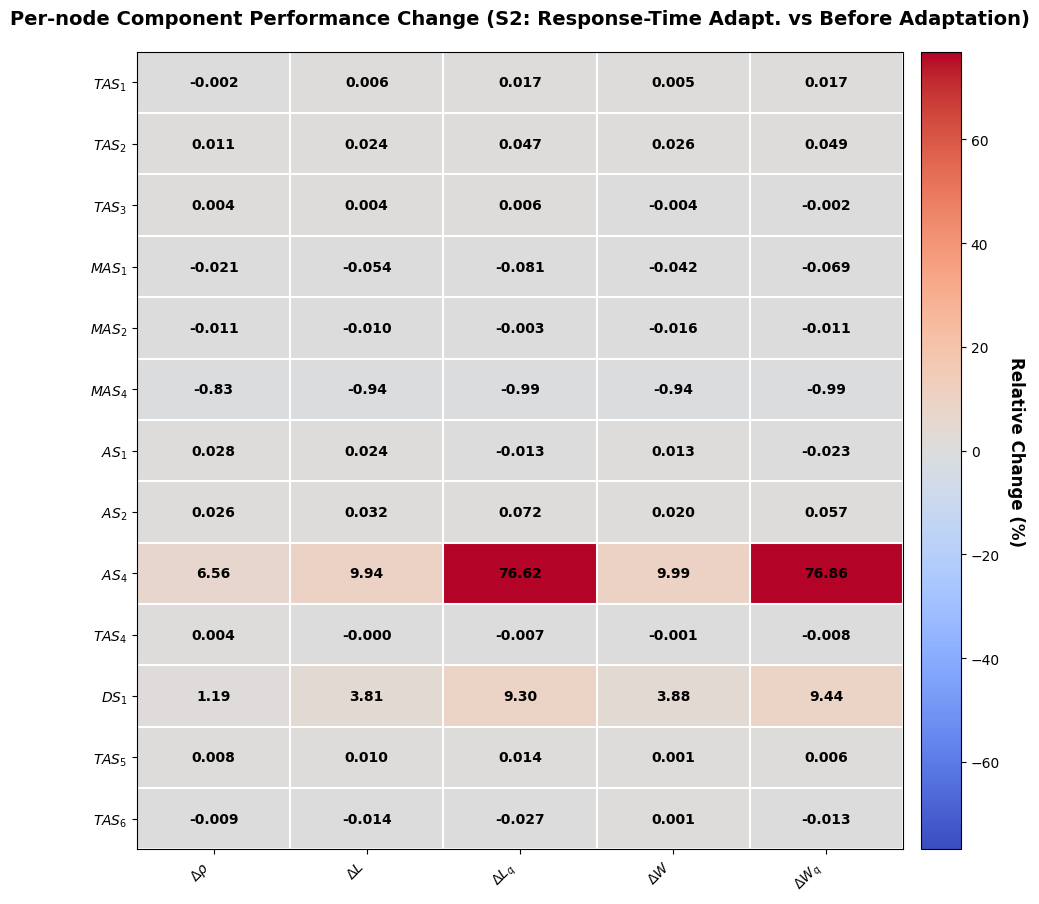

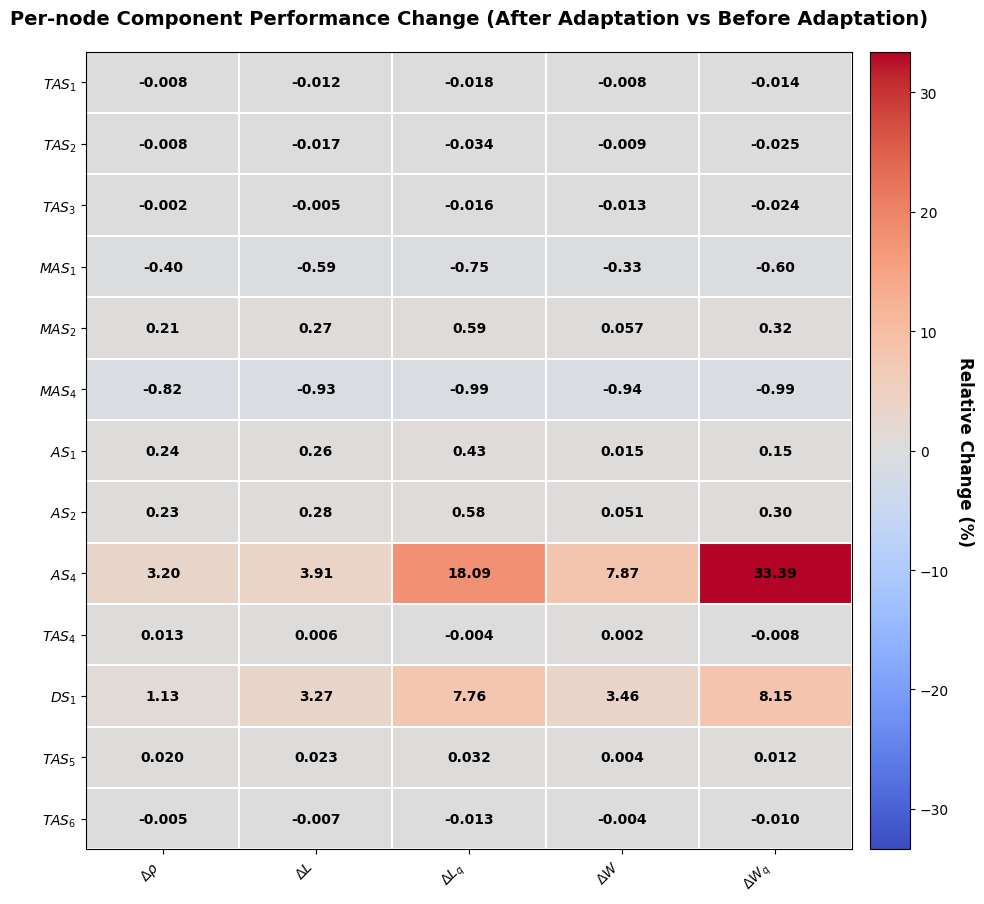

In [7]:
_diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
_diff_labels = [
    r"$\Delta \rho$",
    r"$\Delta L$",
    r"$\Delta L_q$",
    r"$\Delta W$",
    r"$\Delta W_q$",
]
_bl_nodes = _nodes["baseline"]
for _a in ["s1", "s2", "aggregate"]:
    _ac_nodes = _nodes[_a]
    _rows = []
    for _i in range(len(_ac_nodes)):
        _b_row = _bl_nodes.iloc[_i]
        _c_row = _ac_nodes.iloc[_i]
        _row = {"key": _c_row["key"]}
        for _m in _diff_metrics:
            _b, _c = float(_b_row[_m]), float(_c_row[_m])
            _row[_m] = ((_c - _b) / abs(_b)) if _b else 0.0
        _rows.append(_row)
    _deltas = pd.DataFrame(_rows)
    plot_nd_diffmap(
        deltas=_deltas,
        nodes=_deltas["key"].tolist(),
        metrics=_diff_metrics,
        labels=_diff_labels,
        title=f"Per-node Component Performance Change ({_DISPLAY[_a]} vs {_DISPLAY['baseline']})",
        file_path=str(_IMG_ROOT / _a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Per-node confidence-interval bands (stochastic-only)

For each adaptation, plot the per-node mean with a 95 % CI error bar (half-width = `z * sigma / sqrt(reps)` using the replication-level sigma from the `_std` columns). The analytic closed-form baseline is overlaid as red `x` markers so the two methods can be eyeballed against each other: the analytic value should fall INSIDE the stochastic CI when the engine is calibrated correctly.

Both `rho` and `W` get their own panels per adaptation.

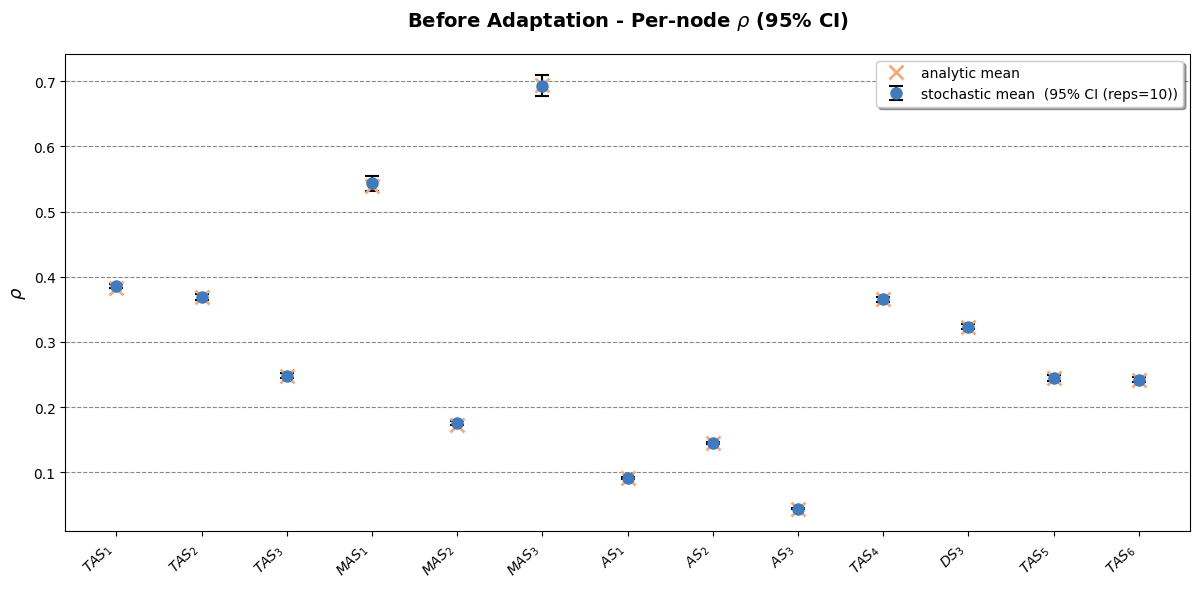

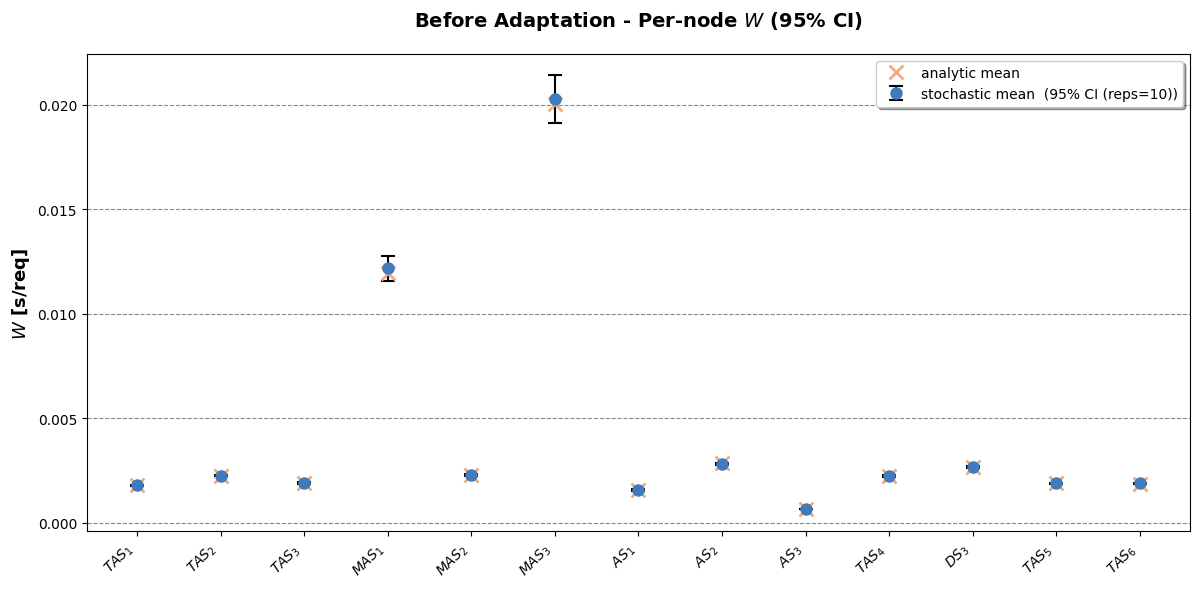

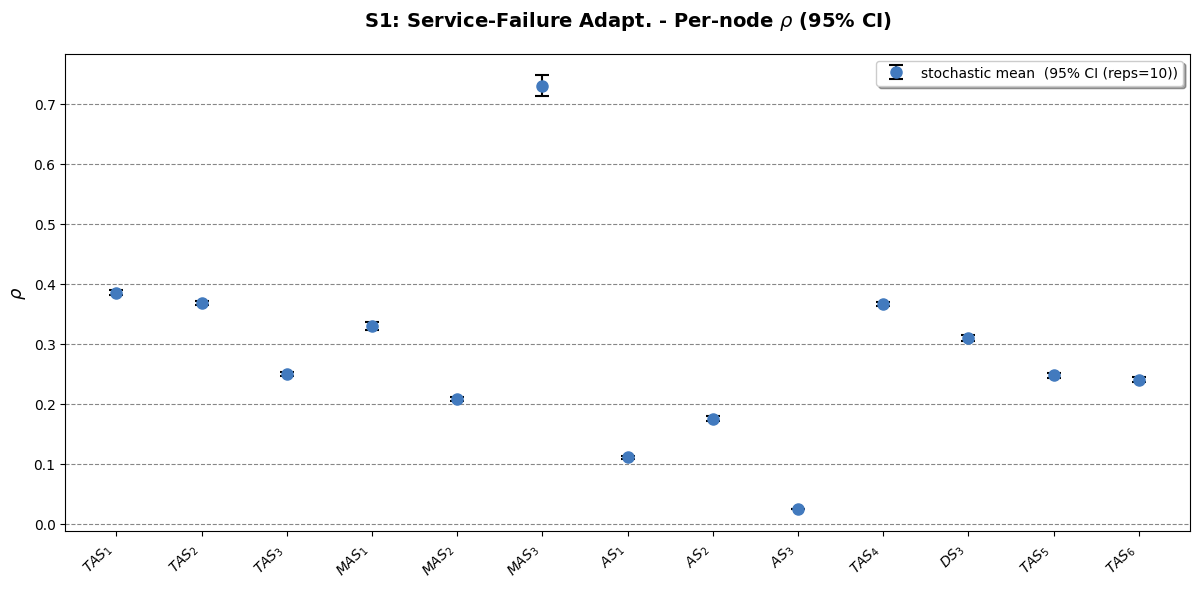

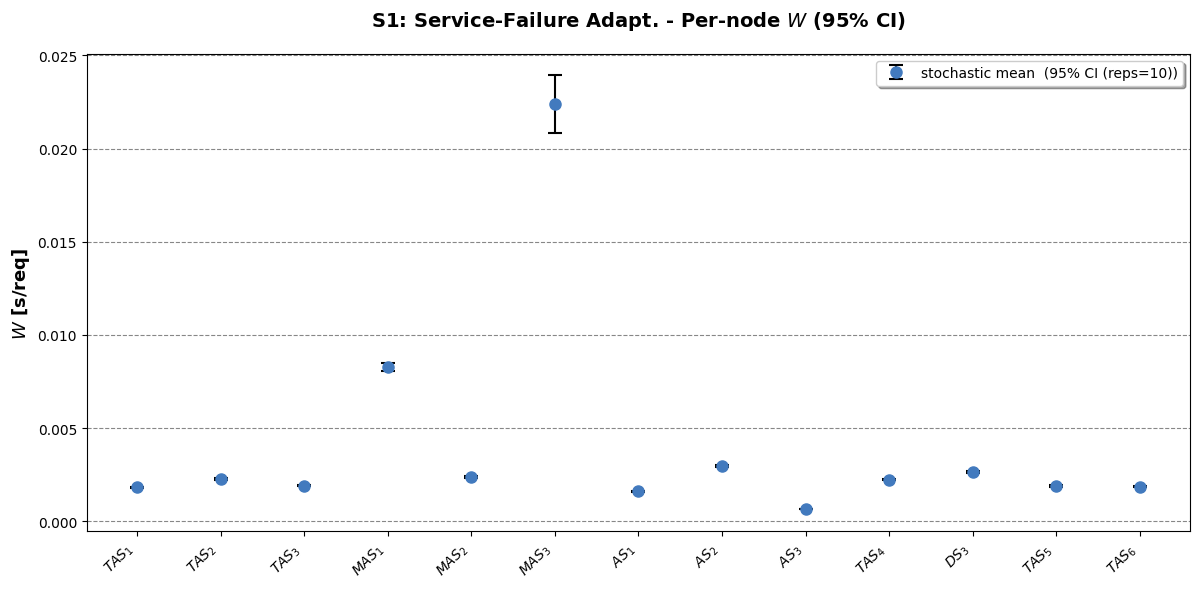

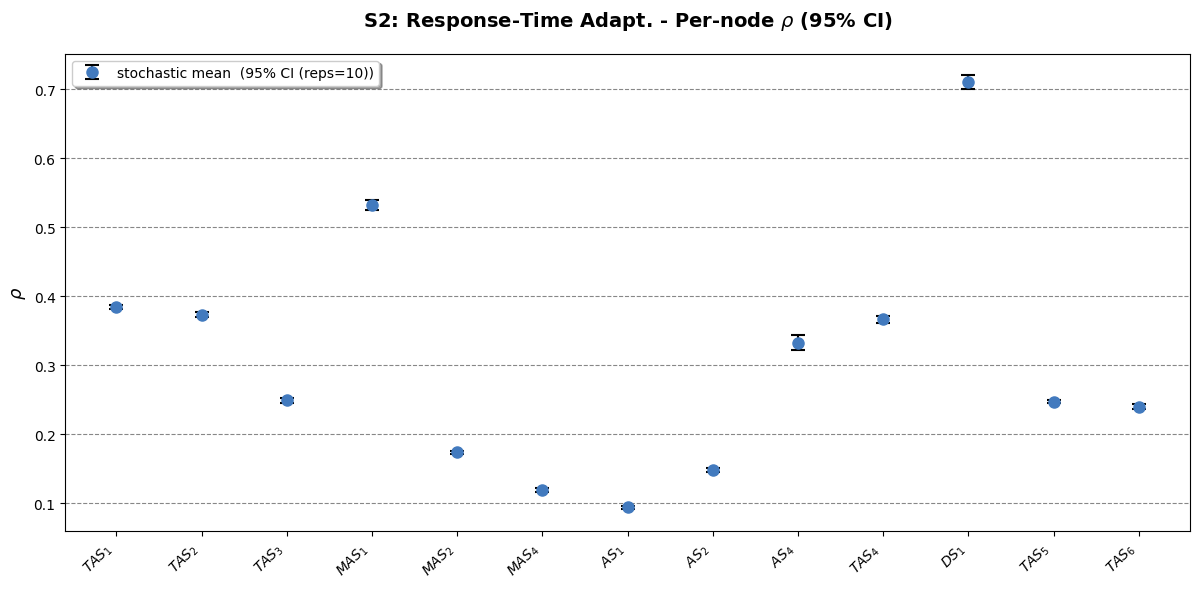

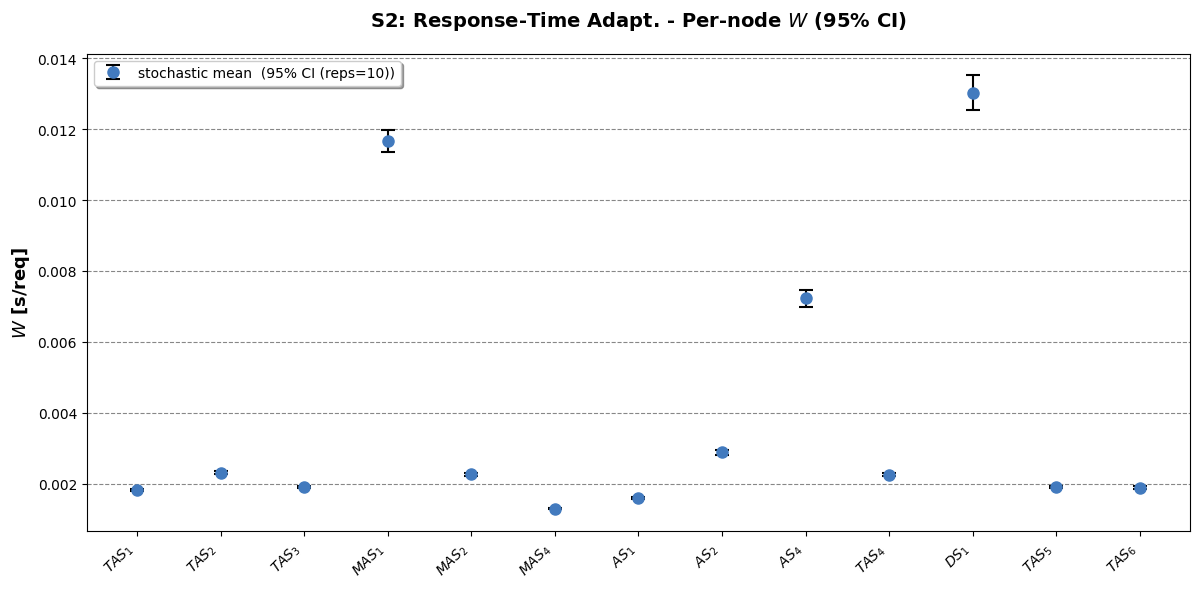

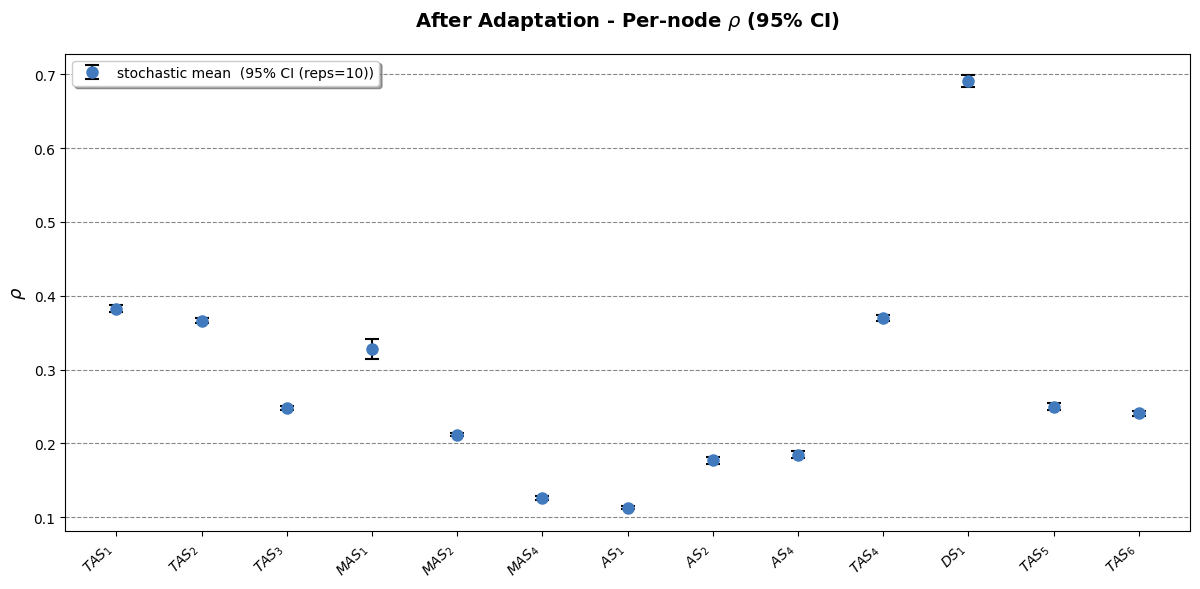

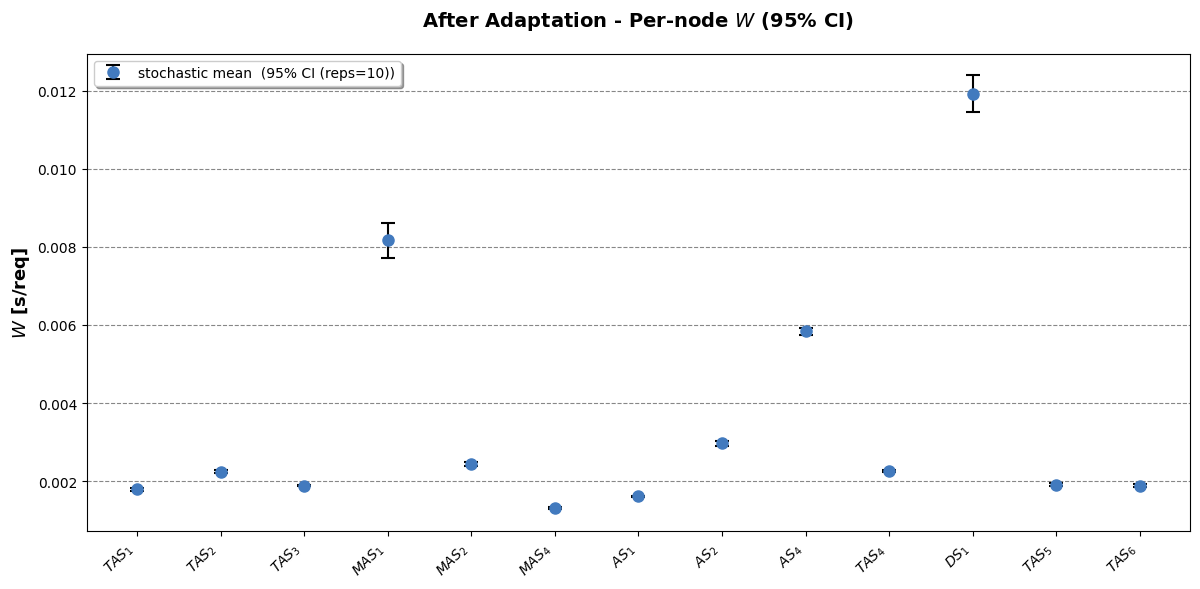

In [8]:
for _a in _ADAPTATIONS:
    plot_nd_ci(
        nds=_nodes[_a],
        metric="rho",
        reference=_analytic_baseline_nodes if _a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\rho$",
        confidence=0.95,
        reps=_mc["replications"],
        title=f"{_DISPLAY[_a]} - Per-node $\\rho$ (95% CI)",
        file_path=str(_IMG_ROOT / _a),
        fname="nd_ci_rho.png")
    plot_nd_ci(
        nds=_nodes[_a],
        metric="W",
        reference=_analytic_baseline_nodes if _a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$W$ [s/req]",
        confidence=0.95,
        reps=_mc["replications"],
        title=f"{_DISPLAY[_a]} - Per-node $W$ (95% CI)",
        file_path=str(_IMG_ROOT / _a),
        fname="nd_ci_W.png")

## 7. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive R1 / R2 / R3. Log y-axis because metrics span several orders of magnitude.

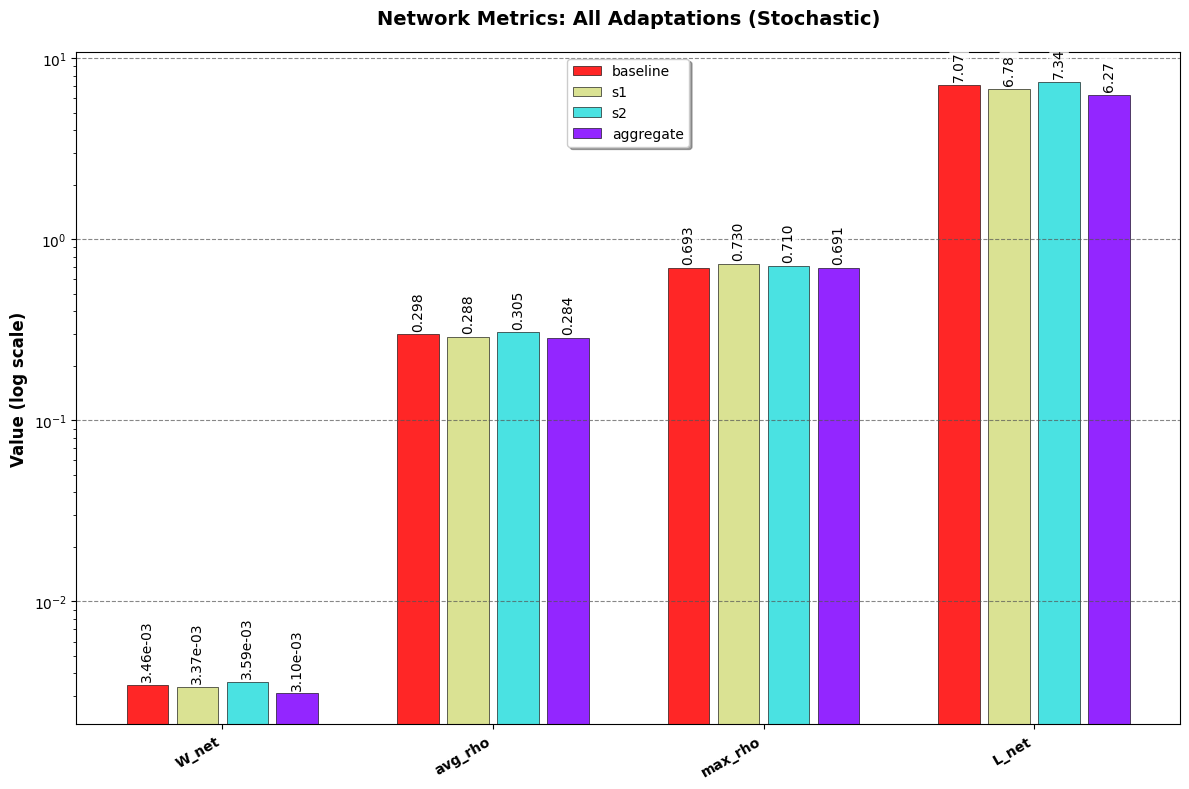

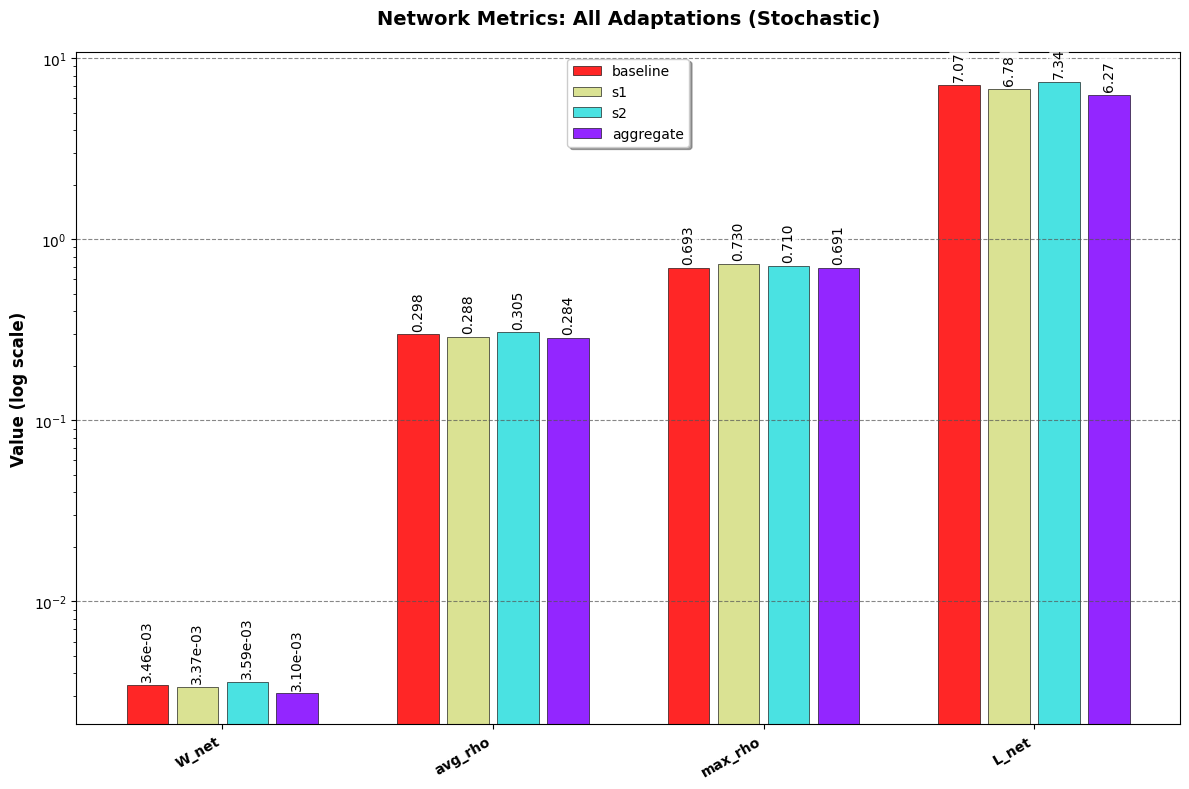

In [9]:
_bar_metrics = ["W_net", "avg_rho", "max_rho", "L_net"]
plot_net_bars(
    nets=[_nets[_a] for _a in _ADAPTATIONS],
    names=_ADAPTATIONS,
    metrics=_bar_metrics,
    title="Network Metrics: All Adaptations (Stochastic)",
    file_path=str(_IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 8. Network-wide delta (% change vs baseline)

Semantic colouring: negative delta = improvement (green), positive = degradation (red).

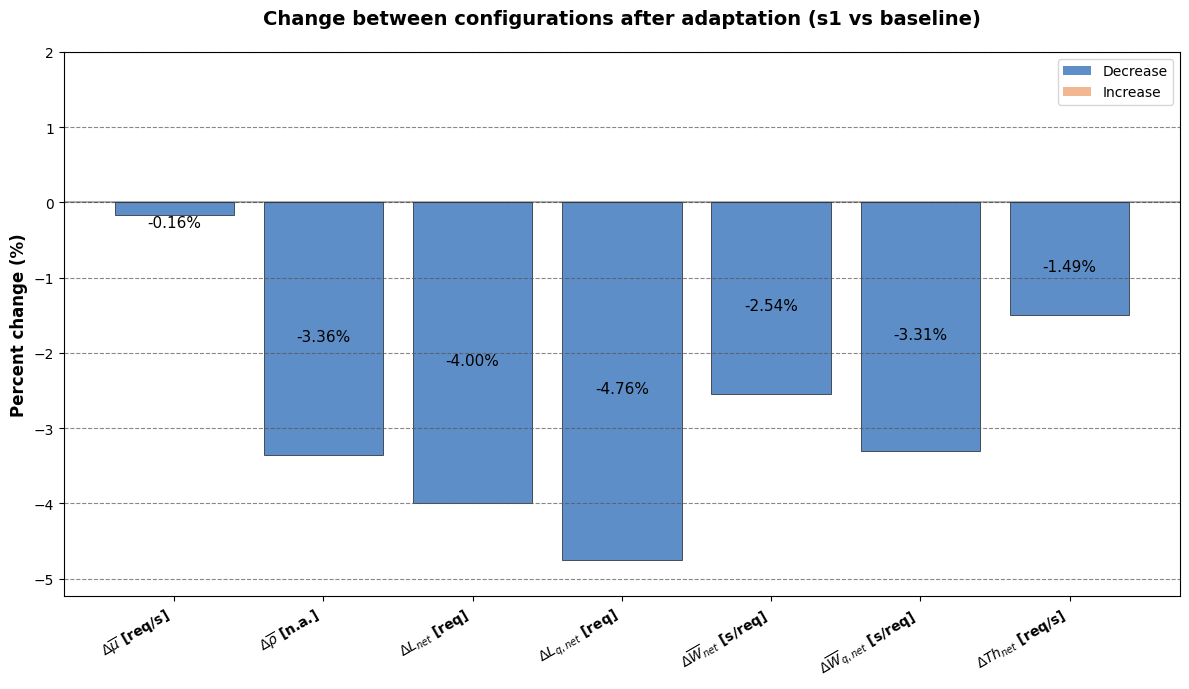

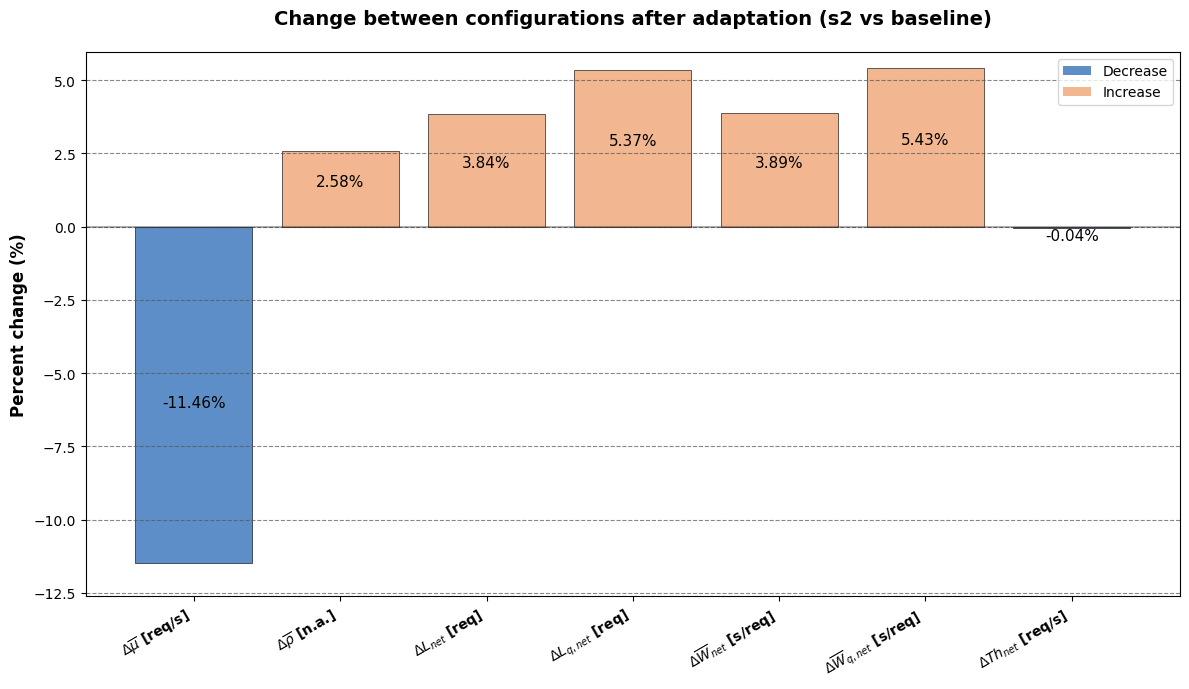

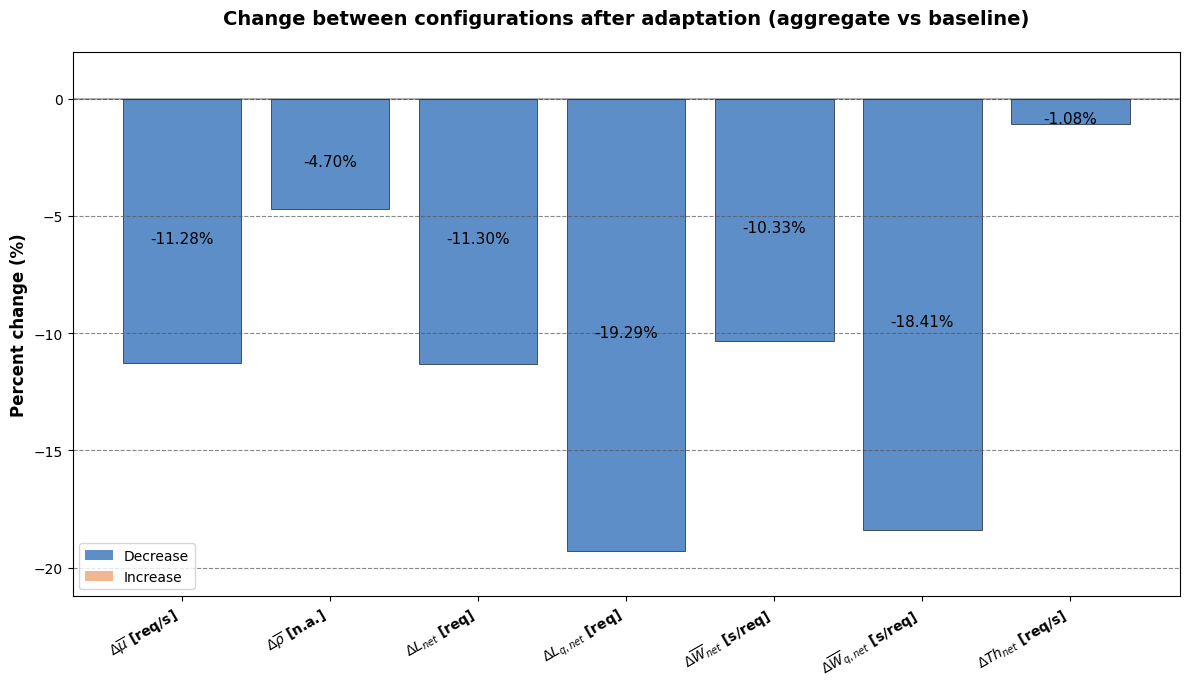

In [10]:
_delta_metrics = [
    "avg_mu", "avg_rho",
    "L_net", "Lq_net",
    "W_net", "Wq_net",
    "total_throughput",
]
_delta_labels = [
    r"$\Delta \overline{\mu}$ [req/s]",
    r"$\Delta \overline{\rho}$ [n.a.]",
    r"$\Delta L_{net}$ [req]",
    r"$\Delta L_{q,net}$ [req]",
    r"$\Delta \overline{W}_{net}$ [s/req]",
    r"$\Delta \overline{W}_{q,net}$ [s/req]",
    r"$\Delta Th_{net}$ [req/s]",
]
_bl = _nets["baseline"].iloc[0]
for _a in ["s1", "s2", "aggregate"]:
    _ac = _nets[_a].iloc[0]
    _row = {
        _m: (_ac[_m] - _bl[_m]) / _bl[_m] if _bl[_m] else 0.0
        for _m in _delta_metrics
    }
    plot_net_delta(
        deltas=pd.DataFrame([_row]),
        metrics=_delta_metrics,
        labels=_delta_labels,
        title=f"Change between configurations after adaptation ({_a} vs baseline)",
        file_path=str(_IMG_ROOT / _a),
        fname="net_delta_vs_baseline.png")

## 9. R1 / R2 / R3 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):
- **R1** Availability: `fail_rate <= 0.03 %`
- **R2** Performance: `resp_time <= 26 ms`
- **R3** Minimise `cost` subject to R1 and R2 (no numeric threshold; passes iff R1 and R2 hold).

In [11]:
_req_rows = []
for _a in _ADAPTATIONS:
    _r = _reqs[_a]
    _req_rows.append({
        "adaptation": _a,
        "R1 fail_rate": _r["R1"]["value"],
        "R1 pass": _r["R1"]["pass"],
        "R2 resp_time (s)": _r["R2"]["value"],
        "R2 pass": _r["R2"]["pass"],
        "R3 pass": _r["R3"]["pass"],
    })
pd.DataFrame(_req_rows).set_index("adaptation")

,R1 fail_rate,R1 pass,R2 resp_time (s),R2 pass,R3 pass
adaptation,,,,,
baseline,0.0,True,0.003457,True,True
s1,0.0,True,0.003369,True,True
s2,0.0,True,0.003591,True,True
aggregate,0.0,True,0.003100,True,True


## Summary

At the nominal 345 req/s arrival rate, the SimPy DES produces per-node W, L, rho / CI bands that the analytic closed-form solution falls inside, validating both methods.

**Next method in the pipeline**: `dimensional.ipynb` (PyDASA pi-groups + Monte-Carlo sensitivity).